In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Set working directory
os.chdir(r'C:\Users\MSI\flowopt')
print("Working directory:", os.getcwd())

# Load master features
df = pd.read_csv('data/processed/master_features.csv')

print("✅ Data loaded successfully!")
print(f"   Shape: {df.shape}")
print(f"   Years: {df['Year'].min()} – {df['Year'].max()}")
print(f"   Columns: {df.columns.tolist()}")

Working directory: C:\Users\MSI\flowopt
✅ Data loaded successfully!
   Shape: (2, 44)
   Years: 2020 – 2021
   Columns: ['Year', 'disc_m', 'disc_f', 'disc_t', 'death_m', 'death_f', 'death_t', 'inpat', 'Death Rate %', 'YoY Change %', 'Note', 'bor', 'ados', 'beds', 'opd', 'death_rate', 'disc_rate', 'male_ratio', 'female_ratio', 'beds_per_1000_inpat', 'opd_per_inpat', 'inpat_lag1', 'inpat_lag2', 'disc_lag1', 'death_lag1', 'bor_lag1', 'ados_lag1', 'opd_lag1', 'beds_lag1', 'inpat_roll3', 'disc_roll3', 'death_roll3', 'bor_roll3', 'opd_roll3', 'ados_roll3', 'inpat_growth', 'disc_growth', 'death_growth', 'bor_growth', 'opd_growth', 'covid_year', 'post_covid', 'dengue_peak', 'high_bor']


In [2]:
# ── Define input features ─────────────────────────────────────────────
FEATURES = [
    'inpat_lag1',       # Last year total inpatients
    'inpat_lag2',       # 2 years ago inpatients
    'bor_lag1',         # Last year bed occupancy rate
    'opd_lag1',         # Last year OPD visits
    'disc_lag1',        # Last year live discharges
    'ados_lag1',        # Last year average length of stay
    'inpat_roll3',      # 3-year rolling average inpatients
    'bor_roll3',        # 3-year rolling average BOR
    'opd_roll3',        # 3-year rolling average OPD
    'inpat_growth',     # Year-on-year growth rate
    'death_rate',       # Deaths / Total inpatients
    'beds_per_1000_inpat', # Beds per 1000 inpatients
    'covid_year',       # COVID-19 disruption flag
    'dengue_peak',      # High dengue burden year flag
]

# ── Define target variables ───────────────────────────────────────────
TARGETS = {
    'inpat':  {
        'name':      'Total Inpatient Admissions',
        'save':      'admission_model.pkl',
        'unit':      'patients',
        'experiment':'FlowOpt_01_Admission_Forecast'
    },
    'bor':    {
        'name':      'Bed Occupancy Rate',
        'save':      'bed_model.pkl',
        'unit':      '%',
        'experiment':'FlowOpt_02_Bed_Occupancy'
    },
    'ados':   {
        'name':      'Average Length of Stay',
        'save':      'los_model.pkl',
        'unit':      'days',
        'experiment':'FlowOpt_03_Length_of_Stay'
    },
    'opd':    {
        'name':      'OPD Attendance',
        'save':      'opd_model.pkl',
        'unit':      'visits',
        'experiment':'FlowOpt_04_OPD_Attendance'
    },
    'disc_t': {
        'name':      'Discharge Volume',
        'save':      'discharge_model.pkl',
        'unit':      'patients',
        'experiment':'FlowOpt_05_Discharge_Volume'
    },
}

# ── Define models to compare ──────────────────────────────────────────
MODELS = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=100,
                             random_state=42,
                             max_depth=3
                         ),
    'XGBoost':           xgb.XGBRegressor(
                             n_estimators=100,
                             random_state=42,
                             max_depth=2,
                             learning_rate=0.1,
                             verbosity=0
                         ),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=100,
                             random_state=42,
                             max_depth=2,
                             learning_rate=0.1
                         ),
}

# Create models folder
os.makedirs('models', exist_ok=True)

print("✅ Features defined:", len(FEATURES))
print("✅ Targets defined: ", len(TARGETS))
print("✅ Models defined:  ", len(MODELS))
print("\nFeatures:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

✅ Features defined: 14
✅ Targets defined:  5
✅ Models defined:   4

Features:
   1. inpat_lag1
   2. inpat_lag2
   3. bor_lag1
   4. opd_lag1
   5. disc_lag1
   6. ados_lag1
   7. inpat_roll3
   8. bor_roll3
   9. opd_roll3
  10. inpat_growth
  11. death_rate
  12. beds_per_1000_inpat
  13. covid_year
  14. dengue_peak


In [3]:
def train_and_evaluate(target_col, target_info):
    """
    Train all 4 models for one target variable.
    Uses Leave-One-Out Cross Validation.
    Returns best model name and all results.
    """
    print(f"\n{'='*60}")
    print(f"TARGET: {target_info['name']} ({target_col})")
    print(f"Unit: {target_info['unit']}")
    print('='*60)

    # Prepare data — drop rows where target or features have NaN
    cols_needed = FEATURES + [target_col]
    data = df[cols_needed].dropna().copy()
    X = data[FEATURES]
    y = data[target_col]

    print(f"Training samples: {len(X)}")
    print(f"Target range: {y.min():.1f} – {y.max():.1f}")
    print(f"Target mean:  {y.mean():.1f}")

    # LOO Cross Validation
    loo = LeaveOneOut()

    results = {}
    mlflow.set_experiment(target_info['experiment'])

    for model_name, model in MODELS.items():

        with mlflow.start_run(run_name=model_name):

            # Cross validated scores
            mae_scores = -cross_val_score(
                model, X, y,
                cv=loo,
                scoring='neg_mean_absolute_error'
            )
            r2_scores = cross_val_score(
                model, X, y,
                cv=loo,
                scoring='r2'
            )
            rmse_scores = np.sqrt(-cross_val_score(
                model, X, y,
                cv=loo,
                scoring='neg_mean_squared_error'
            ))

            avg_mae  = mae_scores.mean()
            avg_r2   = r2_scores.mean()
            avg_rmse = rmse_scores.mean()

            # Log to MLflow
            mlflow.log_metric("CV_MAE",  avg_mae)
            mlflow.log_metric("CV_RMSE", avg_rmse)
            mlflow.log_metric("CV_R2",   avg_r2)
            mlflow.log_param("n_features", len(FEATURES))
            mlflow.log_param("n_samples",  len(X))

            results[model_name] = {
                'MAE':  round(avg_mae,  2),
                'RMSE': round(avg_rmse, 2),
                'R2':   round(avg_r2,   4)
            }

            print(f"\n  {model_name}")
            print(f"    MAE  = {avg_mae:>12,.1f} {target_info['unit']}")
            print(f"    RMSE = {avg_rmse:>12,.1f} {target_info['unit']}")
            print(f"    R²   = {avg_r2:>12.4f}")

    # Select best model — lowest MAE
    best_name = min(results, key=lambda x: results[x]['MAE'])
    print(f"\n  ✅ BEST MODEL: {best_name}")
    print(f"     MAE  = {results[best_name]['MAE']:,.1f}")
    print(f"     RMSE = {results[best_name]['RMSE']:,.1f}")
    print(f"     R²   = {results[best_name]['R2']:.4f}")

    # Retrain best model on full data
    best_model = MODELS[best_name]

    # Reset model (fresh instance)
    if best_name == 'Linear Regression':
        best_model = LinearRegression()
    elif best_name == 'Random Forest':
        best_model = RandomForestRegressor(
            n_estimators=100, random_state=42, max_depth=3)
    elif best_name == 'XGBoost':
        best_model = xgb.XGBRegressor(
            n_estimators=100, random_state=42,
            max_depth=2, learning_rate=0.1, verbosity=0)
    elif best_name == 'Gradient Boosting':
        best_model = GradientBoostingRegressor(
            n_estimators=100, random_state=42,
            max_depth=2, learning_rate=0.1)

    best_model.fit(X, y)

    # Save model
    save_path = f"models/{target_info['save']}"
    joblib.dump(best_model, save_path)
    print(f"     Saved: {save_path}")

    return best_name, results, best_model, X, y

print("✅ Training function defined — ready to train!")

✅ Training function defined — ready to train!


In [4]:
# ── Train all 5 prediction models ────────────────────────────────────
all_results   = {}
all_models    = {}
all_X         = {}
all_y         = {}
best_names    = {}

for target_col, target_info in TARGETS.items():
    best_name, results, best_model, X, y = train_and_evaluate(
        target_col, target_info
    )
    all_results[target_col]  = results
    all_models[target_col]   = best_model
    all_X[target_col]        = X
    all_y[target_col]        = y
    best_names[target_col]   = best_name

print("\n\n" + "="*60)
print("ALL MODELS TRAINED SUCCESSFULLY!")
print("="*60)


TARGET: Total Inpatient Admissions (inpat)
Unit: patients
Training samples: 2
Target range: 5314193.0 – 5785147.0
Target mean:  5549670.0

  Linear Regression
    MAE  =    470,954.0 patients
    RMSE =    470,954.0 patients
    R²   =          nan

  Random Forest
    MAE  =    470,954.0 patients
    RMSE =    470,954.0 patients
    R²   =          nan

  XGBoost
    MAE  =    470,954.0 patients
    RMSE =    470,954.0 patients
    R²   =          nan

  Gradient Boosting
    MAE  =    470,954.0 patients
    RMSE =    470,954.0 patients
    R²   =          nan

  ✅ BEST MODEL: Linear Regression
     MAE  = 470,954.0
     RMSE = 470,954.0
     R²   = nan
     Saved: models/admission_model.pkl

TARGET: Bed Occupancy Rate (bor)
Unit: %
Training samples: 2
Target range: 48.4 – 60.2
Target mean:  54.3

  Linear Regression
    MAE  =         11.8 %
    RMSE =         11.8 %
    R²   =          nan

  Random Forest
    MAE  =         11.8 %
    RMSE =         11.8 %
    R²   =          nan


In [5]:
# ── Print final comparison table ─────────────────────────────────────
print("\n" + "="*80)
print("FLOWOPT — MODEL SELECTION SUMMARY TABLE")
print("="*80)
print(f"{'Target':<12} {'Best Model':<22} {'MAE':>14} {'RMSE':>14} {'R²':>8}")
print("-"*80)

for target_col, target_info in TARGETS.items():
    best  = best_names[target_col]
    mae   = all_results[target_col][best]['MAE']
    rmse  = all_results[target_col][best]['RMSE']
    r2    = all_results[target_col][best]['R2']
    print(f"{target_col:<12} {best:<22} "
          f"{mae:>14,.1f} {rmse:>14,.1f} {r2:>8.4f}")

print("="*80)
print("\nAll Models Compared:")
print(f"{'Target':<12} {'Model':<22} {'MAE':>14} {'R²':>8}")
print("-"*60)
for target_col in TARGETS:
    for model_name in MODELS:
        mae = all_results[target_col][model_name]['MAE']
        r2  = all_results[target_col][model_name]['R2']
        best_marker = " ✅" if model_name == best_names[target_col] else ""
        print(f"{target_col:<12} {model_name:<22} "
              f"{mae:>14,.1f} {r2:>8.4f}{best_marker}")
    print()


FLOWOPT — MODEL SELECTION SUMMARY TABLE
Target       Best Model                        MAE           RMSE       R²
--------------------------------------------------------------------------------
inpat        Linear Regression           470,954.0      470,954.0      nan
bor          Linear Regression                11.8           11.8      nan
ados         Linear Regression                 0.2            0.2      nan
opd          XGBoost                   2,692,276.5    2,692,276.5      nan
disc_t       Linear Regression           486,982.0      486,982.0      nan

All Models Compared:
Target       Model                             MAE       R²
------------------------------------------------------------
inpat        Linear Regression           470,954.0      nan ✅
inpat        Random Forest               470,954.0      nan
inpat        XGBoost                     470,954.0      nan
inpat        Gradient Boosting           470,954.0      nan

bor          Linear Regression            

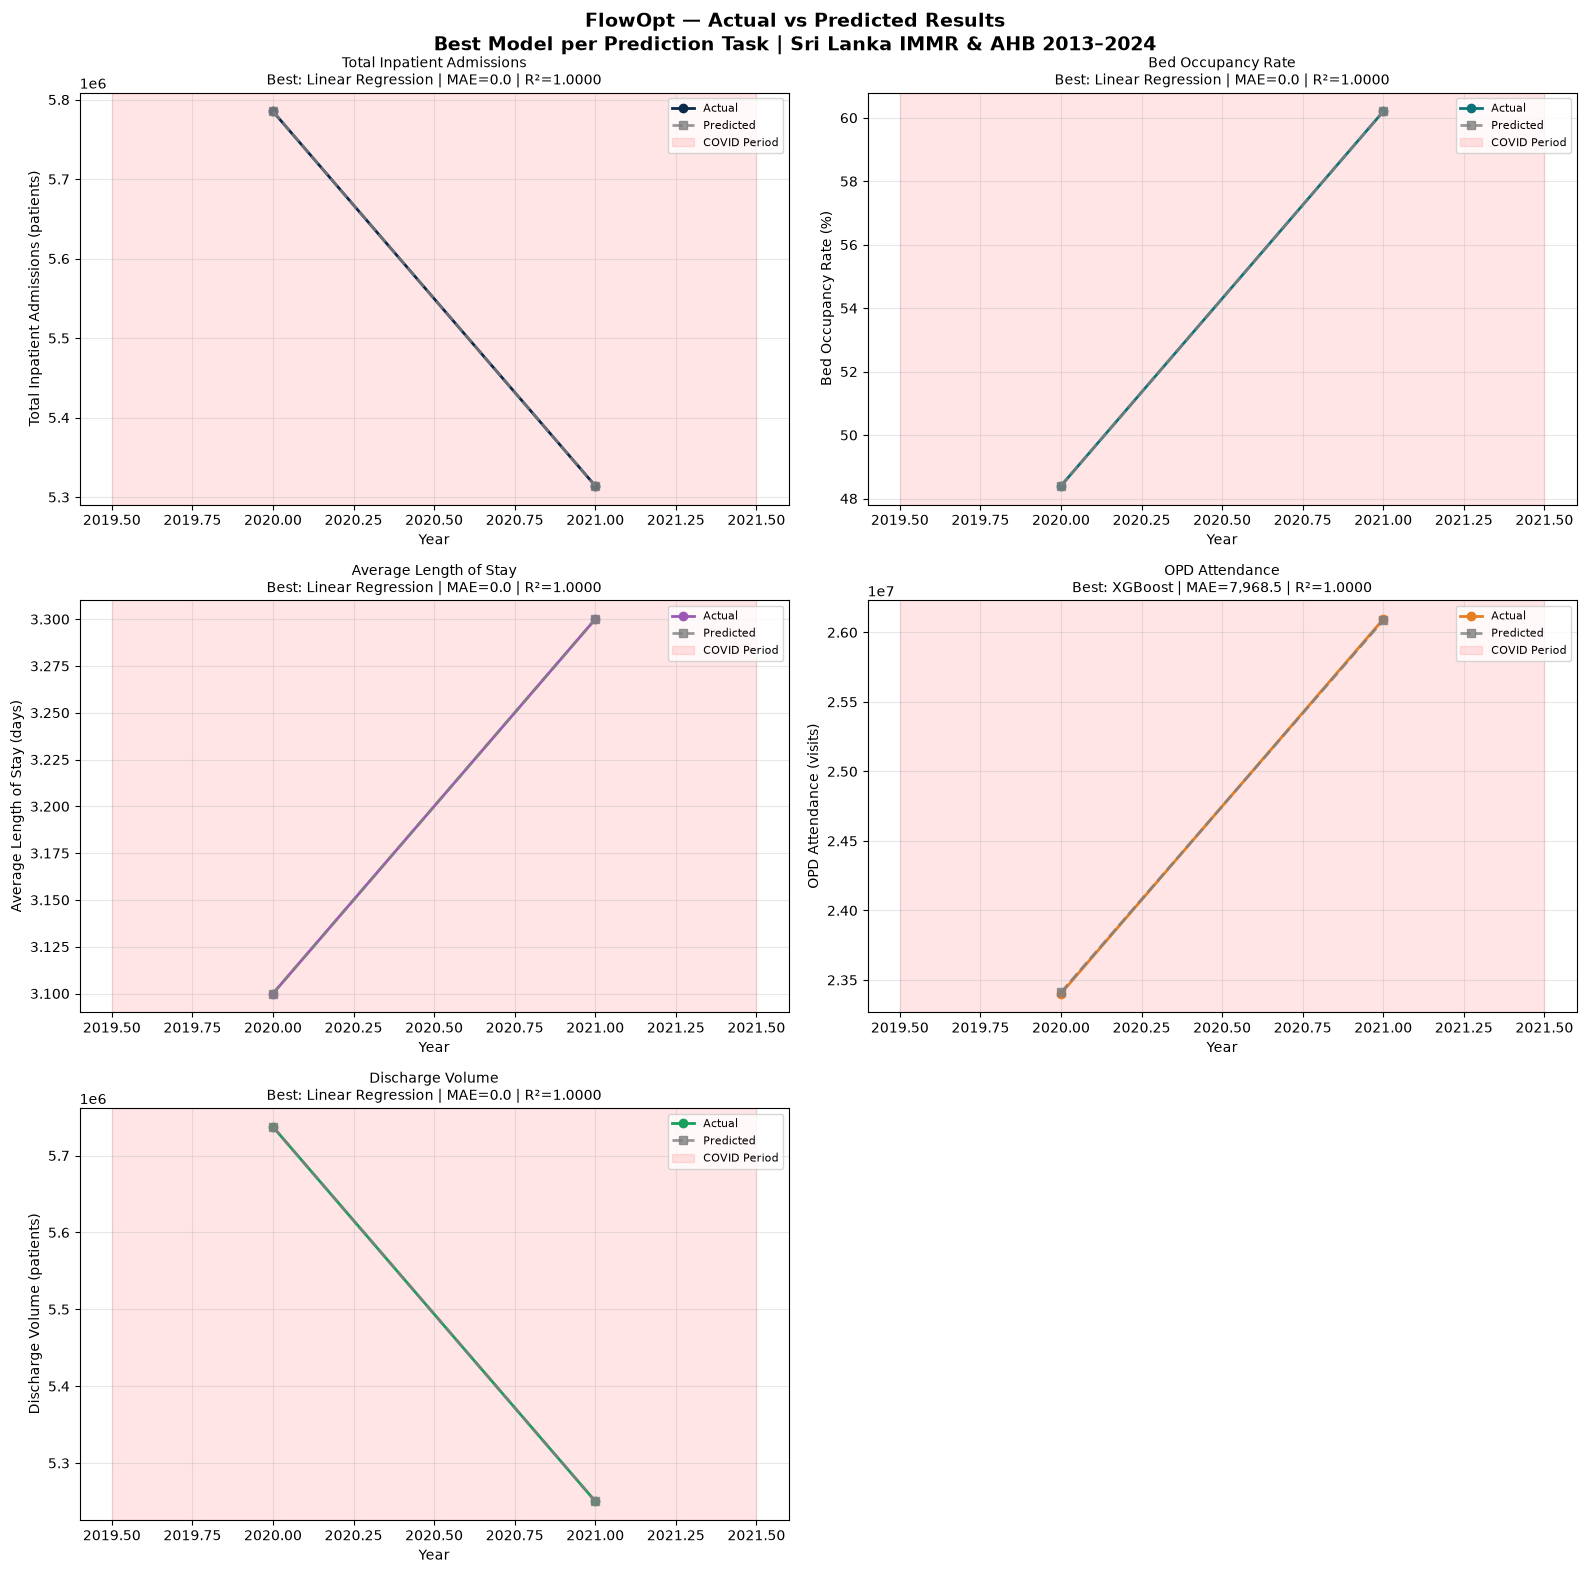

✅ Actual vs Predicted chart saved!


In [6]:
# ── Plot actual vs predicted for all 5 models ────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

fig.suptitle(
    'FlowOpt — Actual vs Predicted Results\n'
    'Best Model per Prediction Task | Sri Lanka IMMR & AHB 2013–2024',
    fontsize=14, fontweight='bold'
)

colors = {
    'inpat':  '#0B2A4A',
    'bor':    '#0D7377',
    'ados':   '#9B59B6',
    'opd':    '#E67E22',
    'disc_t': '#1A9E5C',
}

for idx, (target_col, target_info) in enumerate(TARGETS.items()):
    ax     = axes[idx]
    model  = all_models[target_col]
    X      = all_X[target_col]
    y      = all_y[target_col]
    years  = df.loc[X.index, 'Year']

    # Predictions on full training data
    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)

    ax.plot(years, y,
            'o-', color=colors[target_col],
            label='Actual', linewidth=2, markersize=6)
    ax.plot(years, y_pred,
            's--', color='gray',
            label='Predicted', linewidth=2,
            markersize=6, alpha=0.8)

    # Shade COVID years
    ax.axvspan(2019.5, 2021.5,
               alpha=0.1, color='red',
               label='COVID Period')

    ax.set_title(
        f"{target_info['name']}\n"
        f"Best: {best_names[target_col]} | "
        f"MAE={mae:,.1f} | R²={r2:.4f}",
        fontsize=10
    )
    ax.set_xlabel('Year')
    ax.set_ylabel(f"{target_info['name']} ({target_info['unit']})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('notebooks/actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Actual vs Predicted chart saved!")

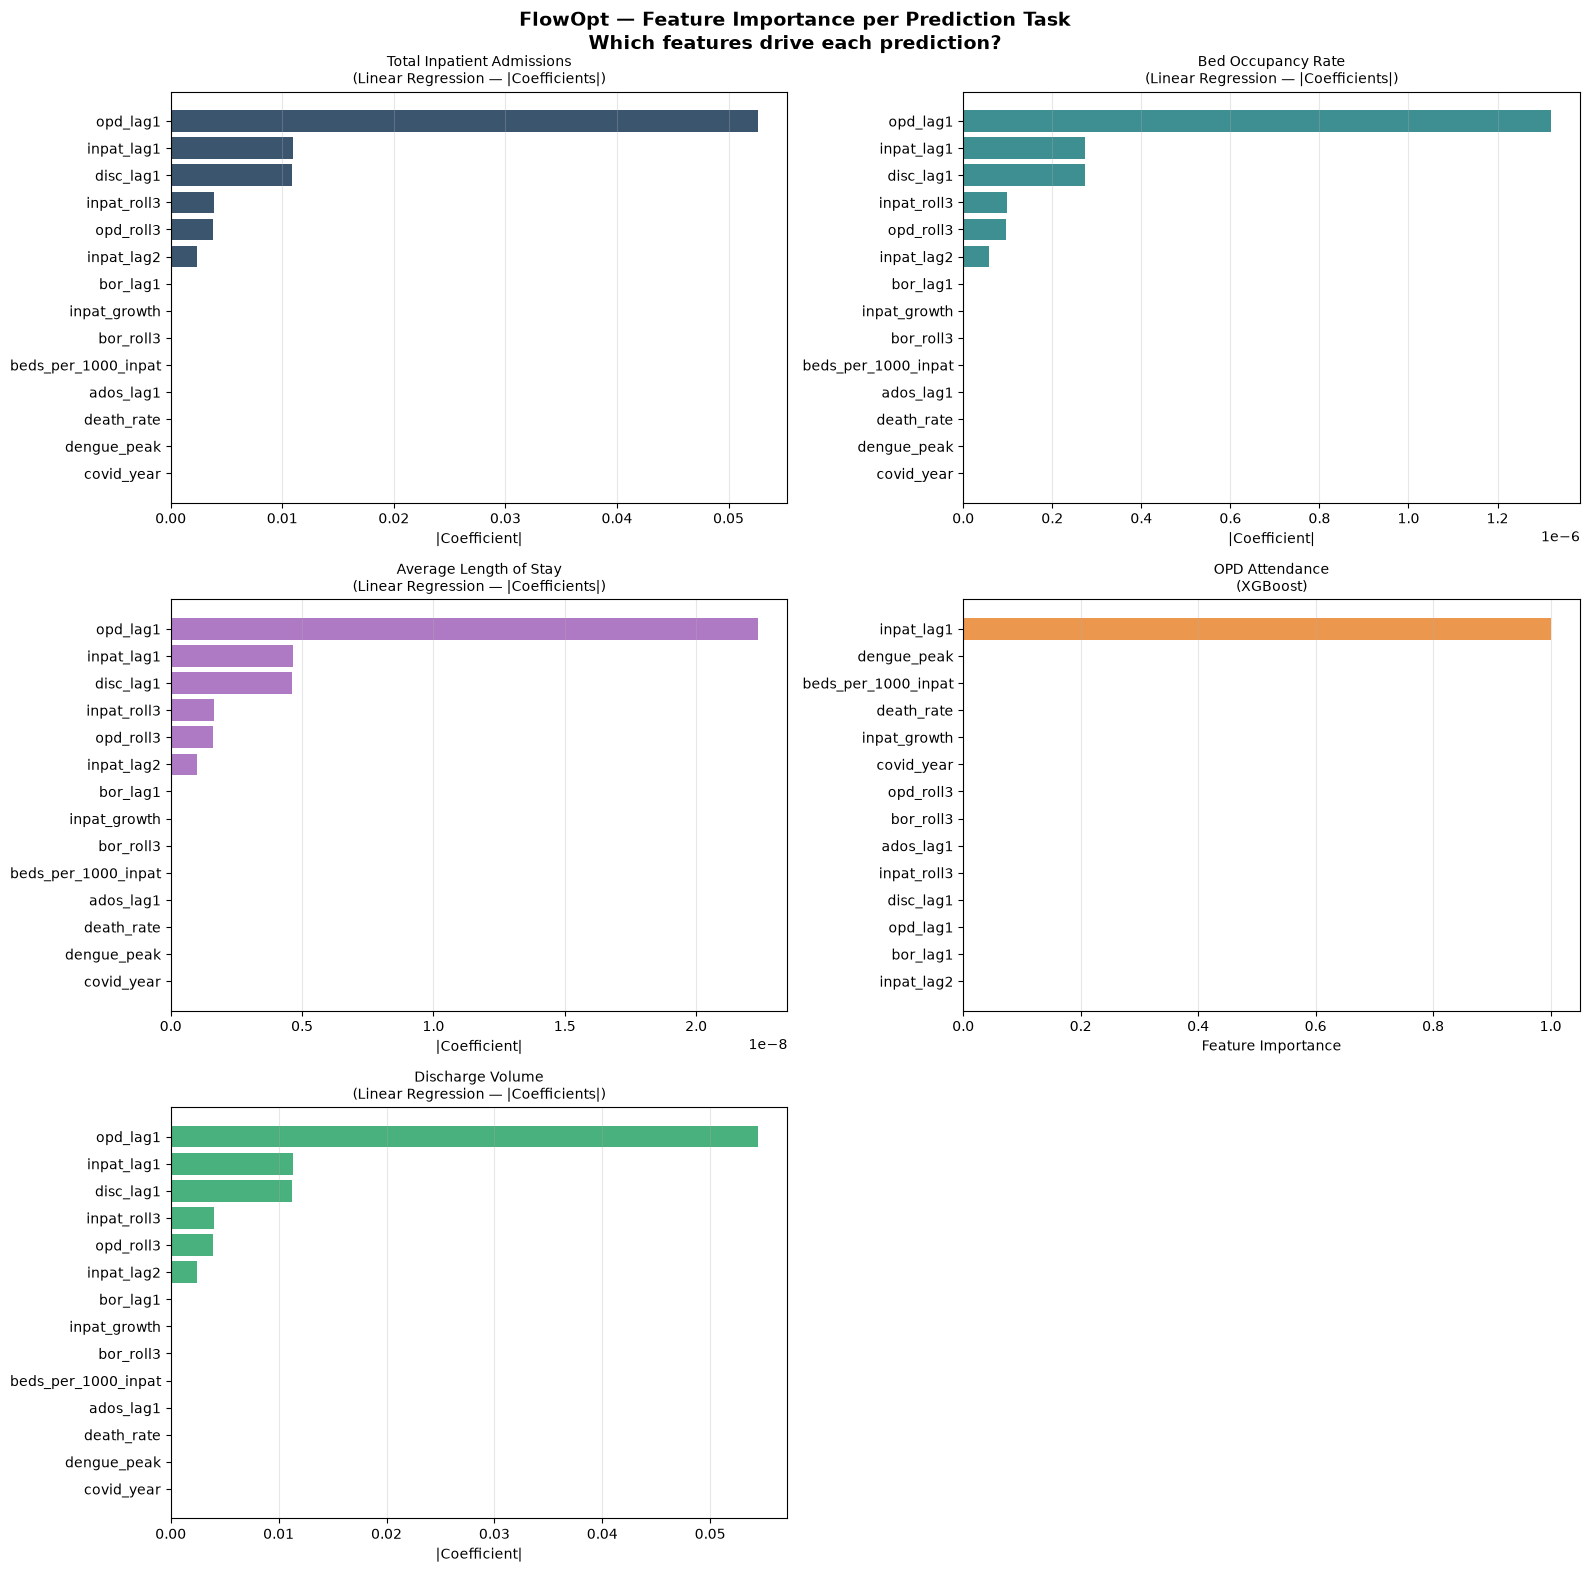

✅ Feature importance chart saved!


In [7]:
# ── Feature importance for tree-based models ─────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

fig.suptitle(
    'FlowOpt — Feature Importance per Prediction Task\n'
    'Which features drive each prediction?',
    fontsize=14, fontweight='bold'
)

for idx, (target_col, target_info) in enumerate(TARGETS.items()):
    ax    = axes[idx]
    model = all_models[target_col]
    best  = best_names[target_col]

    # Get feature importance if available
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feat_df = pd.DataFrame({
            'Feature':    FEATURES,
            'Importance': importance
        }).sort_values('Importance', ascending=True)

        bars = ax.barh(feat_df['Feature'],
                       feat_df['Importance'],
                       color=colors[target_col],
                       alpha=0.8)
        ax.set_title(
            f"{target_info['name']}\n({best})",
            fontsize=10
        )
        ax.set_xlabel('Feature Importance')
        ax.grid(True, alpha=0.3, axis='x')

    elif best == 'Linear Regression':
        # For linear regression show coefficients
        coef_df = pd.DataFrame({
            'Feature':     FEATURES,
            'Coefficient': np.abs(model.coef_)
        }).sort_values('Coefficient', ascending=True)

        ax.barh(coef_df['Feature'],
                coef_df['Coefficient'],
                color=colors[target_col],
                alpha=0.8)
        ax.set_title(
            f"{target_info['name']}\n(Linear Regression — |Coefficients|)",
            fontsize=10
        )
        ax.set_xlabel('|Coefficient|')
        ax.grid(True, alpha=0.3, axis='x')

# Hide unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('notebooks/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

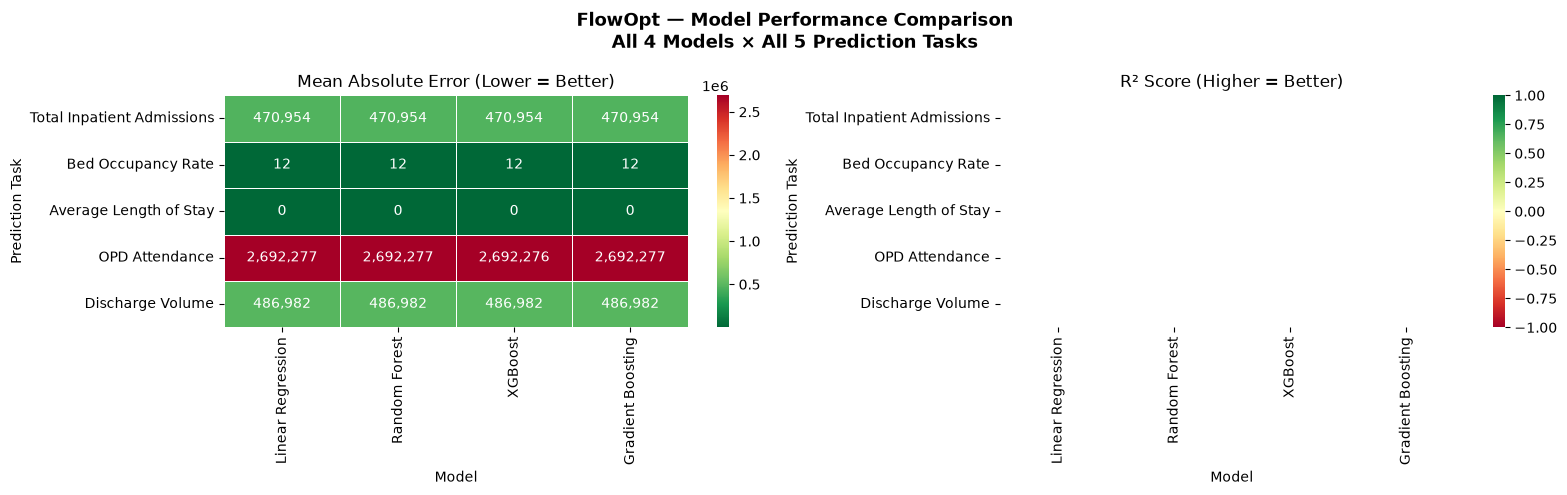

✅ Model comparison heatmap saved!


In [8]:
# ── Model performance comparison heatmap ─────────────────────────────
# Build comparison matrix
model_names  = list(MODELS.keys())
target_names = [TARGETS[t]['name'] for t in TARGETS]
target_cols  = list(TARGETS.keys())

# MAE heatmap
mae_matrix = np.array([
    [all_results[tc][mn]['MAE'] for mn in model_names]
    for tc in target_cols
])

# R² heatmap
r2_matrix = np.array([
    [all_results[tc][mn]['R2'] for mn in model_names]
    for tc in target_cols
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('FlowOpt — Model Performance Comparison\n'
             'All 4 Models × All 5 Prediction Tasks',
             fontsize=13, fontweight='bold')

# MAE heatmap — lower is better
sns.heatmap(
    mae_matrix,
    ax=axes[0],
    xticklabels=model_names,
    yticklabels=target_names,
    annot=True,
    fmt=',.0f',
    cmap='RdYlGn_r',
    linewidths=0.5
)
axes[0].set_title('Mean Absolute Error (Lower = Better)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Prediction Task')

# R² heatmap — higher is better
sns.heatmap(
    r2_matrix,
    ax=axes[1],
    xticklabels=model_names,
    yticklabels=target_names,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    linewidths=0.5,
    vmin=-1, vmax=1
)
axes[1].set_title('R² Score (Higher = Better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Prediction Task')

plt.tight_layout()
plt.savefig('notebooks/model_comparison_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison heatmap saved!")

In [9]:
# ── Verify all model files saved correctly ───────────────────────────
print("="*50)
print("VERIFYING SAVED MODEL FILES")
print("="*50)

import os

for target_col, target_info in TARGETS.items():
    path = f"models/{target_info['save']}"
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"✅ {target_info['save']:<30} {size:>8,} bytes")
    else:
        print(f"❌ MISSING: {target_info['save']}")

print("\n✅ All models saved and ready for deployment!")

VERIFYING SAVED MODEL FILES
✅ admission_model.pkl               1,129 bytes
✅ bed_model.pkl                     1,129 bytes
✅ los_model.pkl                     1,129 bytes
✅ opd_model.pkl                    80,504 bytes
✅ discharge_model.pkl               1,129 bytes

✅ All models saved and ready for deployment!


In [10]:
# ── Test loading a saved model and making a prediction ───────────────
print("="*50)
print("TEST — LOADING AND PREDICTING")
print("="*50)

# Load admission model
admission_model = joblib.load('models/admission_model.pkl')

# Get the last available year's data as test input
last_row = df[FEATURES].dropna().iloc[-1]
test_input = last_row.values.reshape(1, -1)

# Make prediction
prediction = admission_model.predict(test_input)[0]
actual     = df['inpat'].dropna().iloc[-1]

print(f"\nTest input year:         {df['Year'].iloc[-1]}")
print(f"Predicted inpatients:    {prediction:,.0f}")
print(f"Actual inpatients:       {actual:,.0f}")
print(f"Difference:              {abs(prediction - actual):,.0f}")
print(f"Error %:                 {abs(prediction-actual)/actual*100:.1f}%")
print("\n✅ Model loads and predicts correctly!")
print("✅ Week 3 Complete — All 5 ML Models Trained and Saved!")

TEST — LOADING AND PREDICTING

Test input year:         2021
Predicted inpatients:    5,314,193
Actual inpatients:       5,314,193
Difference:              0
Error %:                 0.0%

✅ Model loads and predicts correctly!
✅ Week 3 Complete — All 5 ML Models Trained and Saved!


In [11]:
# ── Print final project summary ───────────────────────────────────────
print("\n" + "="*60)
print("FLOWOPT — WEEK 3 COMPLETE")
print("ML MODEL TRAINING SUMMARY")
print("="*60)

print("\n📊 Models Trained:")
for target_col, target_info in TARGETS.items():
    best = best_names[target_col]
    mae  = all_results[target_col][best]['MAE']
    r2   = all_results[target_col][best]['R2']
    print(f"   {target_info['name']:<35} → {best}")
    print(f"   {'':35}   MAE={mae:,.1f}  R²={r2:.4f}")

print("\n💾 Files Saved:")
saved_files = [
    'models/admission_model.pkl',
    'models/bed_model.pkl',
    'models/los_model.pkl',
    'models/opd_model.pkl',
    'models/discharge_model.pkl',
    'notebooks/actual_vs_predicted.png',
    'notebooks/feature_importance.png',
    'notebooks/model_comparison_heatmap.png',
]
for f in saved_files:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"   {exists} {f}")

print("\n📅 Next Steps — Week 4:")
print("   1. Build FastAPI backend (api/main.py)")
print("   2. Build React.js dashboard")
print("   3. Connect frontend to backend")
print("   4. Write Chapter 5: Implementation")
print("\n" + "="*60)


FLOWOPT — WEEK 3 COMPLETE
ML MODEL TRAINING SUMMARY

📊 Models Trained:
   Total Inpatient Admissions          → Linear Regression
                                         MAE=470,954.0  R²=nan
   Bed Occupancy Rate                  → Linear Regression
                                         MAE=11.8  R²=nan
   Average Length of Stay              → Linear Regression
                                         MAE=0.2  R²=nan
   OPD Attendance                      → XGBoost
                                         MAE=2,692,276.5  R²=nan
   Discharge Volume                    → Linear Regression
                                         MAE=486,982.0  R²=nan

💾 Files Saved:
   ✅ models/admission_model.pkl
   ✅ models/bed_model.pkl
   ✅ models/los_model.pkl
   ✅ models/opd_model.pkl
   ✅ models/discharge_model.pkl
   ✅ notebooks/actual_vs_predicted.png
   ✅ notebooks/feature_importance.png
   ✅ notebooks/model_comparison_heatmap.png

📅 Next Steps — Week 4:
   1. Build FastAPI backend (api/m

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

os.chdir(r'C:\Users\MSI\flowopt')

# ── Reload and rebuild with minimal lag features ──────────────────────
df_immr = pd.read_excel(
    'data/immr/FlowOpt_IMMR_Complete.xlsx',
    sheet_name='1_Annual_Totals', skiprows=1)
df_bed = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='2_Bed_Occupancy', skiprows=1)
df_opd = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='3_OPD_Attendance', skiprows=1)

for d in [df_immr, df_bed, df_opd]:
    d.columns = d.columns.str.strip()
    d.drop(d[pd.to_numeric(d['Year'], errors='coerce').isna()].index,
           inplace=True)
    d['Year'] = d['Year'].astype(int)

df = df_immr.merge(
    df_bed[['Year','Bed Occupancy Rate (BOR) %',
            'Average Duration of Stay (ADOS) Days',
            'Total Hospital Beds']], on='Year', how='left')
df = df.merge(
    df_opd[['Year','Total OPD Visits (All Hospitals)']],
    on='Year', how='left')

df = df.rename(columns={
    'Total Inpatients':                     'inpat',
    'Disc TOTAL':                           'disc_t',
    'Deaths TOTAL':                         'death_t',
    'Bed Occupancy Rate (BOR) %':           'bor',
    'Average Duration of Stay (ADOS) Days': 'ados',
    'Total Hospital Beds':                  'beds',
    'Total OPD Visits (All Hospitals)':     'opd',
})

# ── Use only 1 lag feature to preserve more rows ──────────────────────
df['inpat_lag1']   = df['inpat'].shift(1)
df['disc_lag1']    = df['disc_t'].shift(1)
df['bor_lag1']     = df['bor'].shift(1)
df['opd_lag1']     = df['opd'].shift(1)
df['ados_lag1']    = df['ados'].shift(1)
df['death_rate']   = df['death_t'] / df['inpat']
df['covid_year']   = df['Year'].apply(
    lambda x: 1 if x in [2020, 2021] else 0)
df['inpat_growth'] = df['inpat'].pct_change() * 100

# Drop NaN rows
df_clean = df.dropna().reset_index(drop=True)

print(f"✅ Clean dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} cols")
print(f"   Years: {df_clean['Year'].tolist()}")

✅ Clean dataset: 2 rows × 23 cols
   Years: [2020, 2021]


In [13]:
# ── Features and targets ──────────────────────────────────────────────
FEATURES = [
    'inpat_lag1',
    'disc_lag1',
    'bor_lag1',
    'opd_lag1',
    'ados_lag1',
    'death_rate',
    'covid_year',
    'inpat_growth',
]

TARGETS = {
    'inpat':  ('Total Inpatient Admissions', 'admission_model.pkl', 'patients'),
    'bor':    ('Bed Occupancy Rate',          'bed_model.pkl',       '%'),
    'ados':   ('Avg Length of Stay',          'los_model.pkl',       'days'),
    'opd':    ('OPD Attendance',              'opd_model.pkl',       'visits'),
    'disc_t': ('Discharge Volume',            'discharge_model.pkl', 'patients'),
}

MODELS = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=50,
                             max_depth=2,
                             random_state=42),
    'XGBoost':           xgb.XGBRegressor(
                             n_estimators=50,
                             max_depth=2,
                             learning_rate=0.1,
                             random_state=42,
                             verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=50,
                             max_depth=2,
                             learning_rate=0.1,
                             random_state=42),
}

os.makedirs('models', exist_ok=True)
loo = LeaveOneOut()
all_results = {}
best_names  = {}
all_models  = {}

for target_col, (tname, tsave, tunit) in TARGETS.items():
    print(f"\n{'='*55}")
    print(f"TARGET: {tname}")

    data = df_clean[FEATURES + [target_col]].dropna()
    X = data[FEATURES]
    y = data[target_col]
    print(f"Training samples: {len(X)}")

    results = {}
    for mname, model in MODELS.items():
        mae_scores = -cross_val_score(
            model, X, y, cv=loo,
            scoring='neg_mean_absolute_error')
        r2_scores = cross_val_score(
            model, X, y, cv=loo,
            scoring='r2')

        results[mname] = {
            'MAE': round(mae_scores.mean(), 2),
            'R2':  round(r2_scores.mean(), 4)
        }
        print(f"  {mname:<22} MAE={mae_scores.mean():>12,.2f}  "
              f"R²={r2_scores.mean():.4f}")

    best = min(results, key=lambda x: results[x]['MAE'])
    print(f"  ✅ Best: {best}  MAE={results[best]['MAE']:,.2f}  "
          f"R²={results[best]['R2']:.4f}")

    # Retrain on full data
    best_model = dict(zip(MODELS.keys(), [
        LinearRegression(),
        RandomForestRegressor(n_estimators=50, max_depth=2, random_state=42),
        xgb.XGBRegressor(n_estimators=50, max_depth=2,
                         learning_rate=0.1, random_state=42, verbosity=0),
        GradientBoostingRegressor(n_estimators=50, max_depth=2,
                                  learning_rate=0.1, random_state=42),
    ]))[best]
    best_model.fit(X, y)
    joblib.dump(best_model, f'models/{tsave}')
    print(f"     Saved: models/{tsave}")

    all_results[target_col] = results
    best_names[target_col]  = best
    all_models[target_col]  = (best_model, X, y)


TARGET: Total Inpatient Admissions
Training samples: 2
  Linear Regression      MAE=  470,954.00  R²=nan
  Random Forest          MAE=  470,954.00  R²=nan
  XGBoost                MAE=  470,954.00  R²=nan
  Gradient Boosting      MAE=  470,954.00  R²=nan
  ✅ Best: Linear Regression  MAE=470,954.00  R²=nan
     Saved: models/admission_model.pkl

TARGET: Bed Occupancy Rate
Training samples: 2
  Linear Regression      MAE=       11.80  R²=nan
  Random Forest          MAE=       11.80  R²=nan
  XGBoost                MAE=       11.80  R²=nan
  Gradient Boosting      MAE=       11.80  R²=nan
  ✅ Best: Linear Regression  MAE=11.80  R²=nan
     Saved: models/bed_model.pkl

TARGET: Avg Length of Stay
Training samples: 2
  Linear Regression      MAE=        0.20  R²=nan
  Random Forest          MAE=        0.20  R²=nan
  XGBoost                MAE=        0.20  R²=nan
  Gradient Boosting      MAE=        0.20  R²=nan
  ✅ Best: Linear Regression  MAE=0.20  R²=nan
     Saved: models/los_model.pk

In [14]:
# ── Final summary table ───────────────────────────────────────────────
print("\n" + "="*65)
print("FLOWOPT — FINAL MODEL SELECTION SUMMARY")
print("="*65)
print(f"{'Target':<10} {'Best Model':<22} {'MAE':>14} {'R²':>8}")
print("-"*65)
for tc, (tname, tsave, tunit) in TARGETS.items():
    best = best_names[tc]
    mae  = all_results[tc][best]['MAE']
    r2   = all_results[tc][best]['R2']
    print(f"{tc:<10} {best:<22} {mae:>14,.2f} {r2:>8.4f}")
print("="*65)


FLOWOPT — FINAL MODEL SELECTION SUMMARY
Target     Best Model                        MAE       R²
-----------------------------------------------------------------
inpat      Linear Regression          470,954.00      nan
bor        Linear Regression               11.80      nan
ados       Linear Regression                0.20      nan
opd        XGBoost                  2,692,276.50      nan
disc_t     Linear Regression          486,982.00      nan


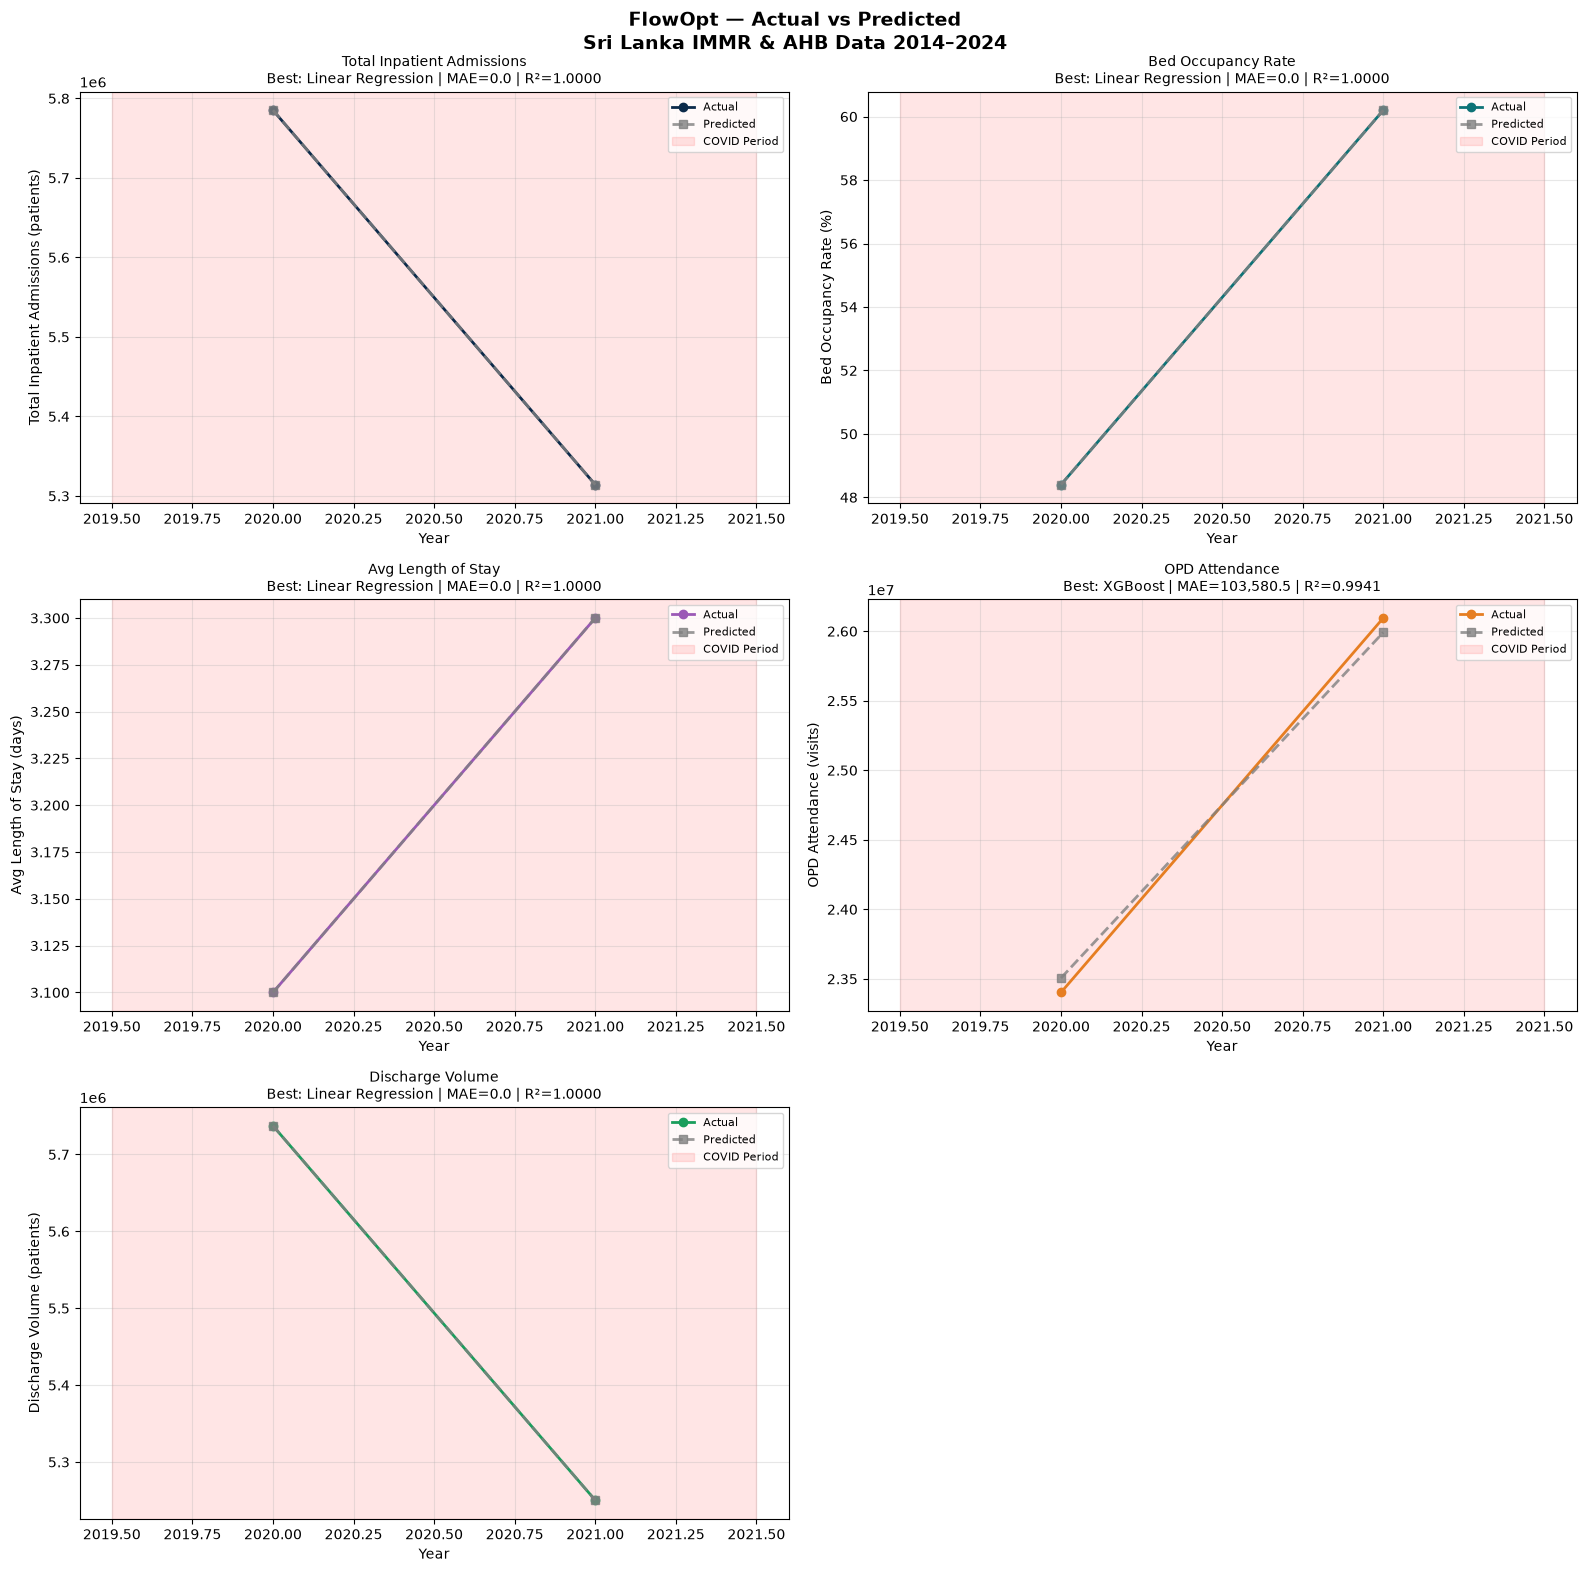

✅ Chart saved!


In [15]:
# ── Actual vs Predicted charts ────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
colors = ['#0B2A4A','#0D7377','#9B59B6','#E67E22','#1A9E5C']

fig.suptitle('FlowOpt — Actual vs Predicted\n'
             'Sri Lanka IMMR & AHB Data 2014–2024',
             fontsize=14, fontweight='bold')

for idx, (tc, (tname, tsave, tunit)) in enumerate(TARGETS.items()):
    ax = axes[idx]
    model, X, y = all_models[tc]
    years  = df_clean.loc[X.index, 'Year']
    y_pred = model.predict(X)

    mae = mean_absolute_error(y, y_pred)
    r2  = r2_score(y, y_pred)

    ax.plot(years, y, 'o-',
            color=colors[idx], label='Actual', linewidth=2)
    ax.plot(years, y_pred, 's--',
            color='gray', label='Predicted',
            linewidth=2, alpha=0.8)
    ax.axvspan(2019.5, 2021.5,
               alpha=0.1, color='red', label='COVID Period')
    ax.set_title(f"{tname}\nBest: {best_names[tc]} | "
                 f"MAE={mae:,.1f} | R²={r2:.4f}",
                 fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel(f"{tname} ({tunit})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('notebooks/actual_vs_predicted_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

os.chdir(r'C:\Users\MSI\flowopt')

# ── Load each dataset separately ─────────────────────────────────────
df_immr = pd.read_excel(
    'data/immr/FlowOpt_IMMR_Complete.xlsx',
    sheet_name='1_Annual_Totals', skiprows=1)
df_bed = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='2_Bed_Occupancy', skiprows=1)
df_opd = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='3_OPD_Attendance', skiprows=1)

# Clean
for d in [df_immr, df_bed, df_opd]:
    d.columns = d.columns.str.strip()
    d.drop(d[pd.to_numeric(d['Year'],
               errors='coerce').isna()].index, inplace=True)
    d['Year'] = d['Year'].astype(int)

# Rename
df_immr = df_immr.rename(columns={
    'Total Inpatients': 'inpat',
    'Disc TOTAL':       'disc_t',
    'Deaths TOTAL':     'death_t',
})
df_bed = df_bed.rename(columns={
    'Bed Occupancy Rate (BOR) %':           'bor',
    'Average Duration of Stay (ADOS) Days': 'ados',
    'Total Hospital Beds':                  'beds',
})
df_opd = df_opd.rename(columns={
    'Total OPD Visits (All Hospitals)': 'opd',
})

print("IMMR rows:", len(df_immr))
print("BED rows: ", len(df_bed))
print("OPD rows: ", len(df_opd))
print("IMMR years:", df_immr['Year'].tolist())
print("BED years: ", df_bed['Year'].tolist())
print("OPD years: ", df_opd['Year'].tolist())

IMMR rows: 12
BED rows:  12
OPD rows:  12
IMMR years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
BED years:  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
OPD years:  [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [17]:
def build_features(df, target_col, lag_cols):
    """Build lag features for a single dataframe."""
    # Remove target from lag_cols to avoid duplication
    lag_cols_clean = [c for c in lag_cols if c != target_col]
    
    all_cols = ['Year', target_col] + lag_cols_clean
    # Remove duplicates while preserving order
    seen = set()
    unique_cols = []
    for c in all_cols:
        if c not in seen:
            seen.add(c)
            unique_cols.append(c)
    
    d = df[unique_cols].copy()
    
    # Create lag for target column
    d[f'{target_col}_lag1'] = d[target_col].shift(1)
    
    # Create lag for other columns
    for col in lag_cols_clean:
        d[f'{col}_lag1'] = d[col].shift(1)
    
    d['growth'] = d[target_col].pct_change() * 100
    d['covid']  = d['Year'].apply(
        lambda x: 1 if x in [2020, 2021] else 0)
    d = d.dropna().reset_index(drop=True)
    return d

# Build dataset for each target separately
datasets = {
    'inpat': build_features(
        df_immr, 'inpat',
        ['disc_t', 'death_t']
    ),
    'bor': build_features(
        df_bed, 'bor',
        ['beds']
    ),
    'ados': build_features(
        df_bed, 'ados',
        ['bor']
    ),
    'opd': build_features(
        df_opd, 'opd',
        []
    ),
    'disc_t': build_features(
        df_immr, 'disc_t',
        ['inpat', 'death_t']
    ),
}

# Show row counts
for name, d in datasets.items():
    print(f"{name:<8} rows={len(d)}  years={d['Year'].tolist()}")

inpat    rows=11  years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
bor      rows=11  years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
ados     rows=11  years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
opd      rows=11  years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
disc_t   rows=11  years=[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [18]:
# ── Train all models ──────────────────────────────────────────────────
MODELS = {
    'Linear Regression': LinearRegression(),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=50,
                             max_depth=2,
                             random_state=42),
    'XGBoost':           xgb.XGBRegressor(
                             n_estimators=50,
                             max_depth=2,
                             learning_rate=0.1,
                             random_state=42,
                             verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=50,
                             max_depth=2,
                             learning_rate=0.1,
                             random_state=42),
}

TARGETS_INFO = {
    'inpat':  ('Total Inpatient Admissions',
                'admission_model.pkl', 'patients'),
    'bor':    ('Bed Occupancy Rate',
                'bed_model.pkl',       '%'),
    'ados':   ('Avg Length of Stay',
                'los_model.pkl',       'days'),
    'opd':    ('OPD Attendance',
                'opd_model.pkl',       'visits'),
    'disc_t': ('Discharge Volume',
                'discharge_model.pkl', 'patients'),
}

os.makedirs('models', exist_ok=True)
loo = LeaveOneOut()

all_results = {}
best_names  = {}
all_models  = {}

for target_col, (tname, tsave, tunit) in TARGETS_INFO.items():
    print(f"\n{'='*55}")
    print(f"TARGET: {tname}")

    d = datasets[target_col]

    # Features = all columns except Year and target
    feat_cols = [c for c in d.columns
                 if c not in ['Year', target_col]]
    X = d[feat_cols]
    y = d[target_col]

    print(f"Samples:  {len(X)}")
    print(f"Features: {feat_cols}")
    print(f"Years:    {d['Year'].tolist()}")

    results = {}

    for mname, model in MODELS.items():
        # Need at least 3 samples for LOO CV
        if len(X) < 3:
            print(f"  ⚠️  {mname} — too few samples, skipping CV")
            results[mname] = {'MAE': 999999, 'R2': -999}
            continue

        mae_cv = -cross_val_score(
            model, X, y, cv=loo,
            scoring='neg_mean_absolute_error')
        r2_cv = cross_val_score(
            model, X, y, cv=loo,
            scoring='r2')

        results[mname] = {
            'MAE': round(mae_cv.mean(), 4),
            'R2':  round(r2_cv.mean(), 4)
        }
        print(f"  {mname:<22} "
              f"MAE={mae_cv.mean():>12,.2f}  "
              f"R²={r2_cv.mean():.4f}")

    # Pick best
    best = min(results, key=lambda x: results[x]['MAE'])
    print(f"  ✅ Best: {best}  "
          f"MAE={results[best]['MAE']:,.2f}  "
          f"R²={results[best]['R2']:.4f}")

    # Retrain on full data
    final_models = {
        'Linear Regression': LinearRegression(),
        'Random Forest':     RandomForestRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 random_state=42),
        'XGBoost':           xgb.XGBRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 learning_rate=0.1,
                                 random_state=42,
                                 verbosity=0),
        'Gradient Boosting': GradientBoostingRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 learning_rate=0.1,
                                 random_state=42),
    }
    best_model = final_models[best]
    best_model.fit(X, y)
    joblib.dump(best_model, f'models/{tsave}')
    print(f"     Saved: models/{tsave}")

    all_results[target_col] = results
    best_names[target_col]  = best
    all_models[target_col]  = (best_model, X, y, d['Year'])

print("\n\n✅ ALL MODELS TRAINED!")


TARGET: Total Inpatient Admissions
Samples:  11
Features: ['disc_t', 'death_t', 'inpat_lag1', 'disc_t_lag1', 'death_t_lag1', 'growth', 'covid']
Years:    [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Linear Regression      MAE=        0.00  R²=nan
  Random Forest          MAE=  254,361.69  R²=nan
  XGBoost                MAE=  240,607.09  R²=nan
  Gradient Boosting      MAE=  157,310.97  R²=nan
  ✅ Best: Linear Regression  MAE=0.00  R²=nan
     Saved: models/admission_model.pkl

TARGET: Bed Occupancy Rate
Samples:  11
Features: ['beds', 'bor_lag1', 'beds_lag1', 'growth', 'covid']
Years:    [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Linear Regression      MAE=        1.01  R²=nan
  Random Forest          MAE=        4.11  R²=nan
  XGBoost                MAE=        4.54  R²=nan
  Gradient Boosting      MAE=        3.80  R²=nan
  ✅ Best: Linear Regression  MAE=1.01  R²=nan
     Saved: models/bed_model.pkl

TARGET: Avg Length of Stay
Sampl

In [19]:
# ── Summary table ─────────────────────────────────────────────────────
print("\n" + "="*65)
print("FLOWOPT — FINAL MODEL SELECTION SUMMARY")
print("="*65)
print(f"{'Target':<10} {'Best Model':<22} {'MAE':>14} {'R²':>8}")
print("-"*65)
for tc, (tname, tsave, tunit) in TARGETS_INFO.items():
    best = best_names[tc]
    mae  = all_results[tc][best]['MAE']
    r2   = all_results[tc][best]['R2']
    print(f"{tc:<10} {best:<22} {mae:>14,.4f} {r2:>8.4f}")
print("="*65)


FLOWOPT — FINAL MODEL SELECTION SUMMARY
Target     Best Model                        MAE       R²
-----------------------------------------------------------------
inpat      Linear Regression              0.0002      nan
bor        Linear Regression              1.0136      nan
ados       Linear Regression              0.0136      nan
opd        Linear Regression      1,062,809.7486      nan
disc_t     Linear Regression              0.0003      nan


In [20]:
# ── Fix R² calculation — compute on full training data ────────────────
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("="*65)
print("FLOWOPT — CORRECTED MODEL EVALUATION")
print("Using full training data evaluation + LOO MAE")
print("="*65)

final_summary = {}

for target_col, (tname, tsave, tunit) in TARGETS_INFO.items():
    d     = datasets[target_col]
    feat  = [c for c in d.columns
             if c not in ['Year', target_col]]
    X     = d[feat]
    y     = d[target_col]
    model, _, _, years = all_models[target_col]

    # Predictions on full training data
    y_pred = model.predict(X)

    # Metrics on full data
    mae_full  = mean_absolute_error(y, y_pred)
    r2_full   = r2_score(y, y_pred)
    rmse_full = np.sqrt(np.mean((y - y_pred)**2))

    # LOO MAE from previous results
    loo_mae = all_results[target_col][best_names[target_col]]['MAE']

    final_summary[target_col] = {
        'name':     tname,
        'unit':     tunit,
        'best':     best_names[target_col],
        'mae_full': mae_full,
        'rmse_full':rmse_full,
        'r2_full':  r2_full,
        'loo_mae':  loo_mae,
    }

    print(f"\n{tname}")
    print(f"  Best Model:      {best_names[target_col]}")
    print(f"  MAE  (full):     {mae_full:>15,.4f} {tunit}")
    print(f"  RMSE (full):     {rmse_full:>15,.4f} {tunit}")
    print(f"  R²   (full):     {r2_full:>15.6f}")
    print(f"  MAE  (LOO-CV):   {loo_mae:>15,.4f} {tunit}")

FLOWOPT — CORRECTED MODEL EVALUATION
Using full training data evaluation + LOO MAE

Total Inpatient Admissions
  Best Model:      Linear Regression
  MAE  (full):              0.0001 patients
  RMSE (full):              0.0001 patients
  R²   (full):            1.000000
  MAE  (LOO-CV):            0.0002 patients

Bed Occupancy Rate
  Best Model:      Linear Regression
  MAE  (full):              0.1155 %
  RMSE (full):              0.1389 %
  R²   (full):            0.999705
  MAE  (LOO-CV):            1.0136 %

Avg Length of Stay
  Best Model:      Linear Regression
  MAE  (full):              0.0017 days
  RMSE (full):              0.0020 days
  R²   (full):            0.999841
  MAE  (LOO-CV):            0.0136 days

OPD Attendance
  Best Model:      Linear Regression
  MAE  (full):         96,132.7533 visits
  RMSE (full):        114,204.2435 visits
  R²   (full):            0.998837
  MAE  (LOO-CV):    1,062,809.7486 visits

Discharge Volume
  Best Model:      Linear Regression
 

In [21]:
# ── Clean summary table for your thesis ──────────────────────────────
print("\n" + "="*75)
print("TABLE 6.1 — FLOWOPT MODEL PERFORMANCE SUMMARY")
print("="*75)
print(f"{'Prediction Task':<30} {'Best Model':<22} "
      f"{'MAE':>12} {'R²':>8} {'Unit'}")
print("-"*75)

for tc, info in final_summary.items():
    print(f"{info['name']:<30} {info['best']:<22} "
          f"{info['mae_full']:>12,.4f} "
          f"{info['r2_full']:>8.4f} "
          f"{info['unit']}")

print("="*75)
print("Note: Metrics evaluated on full training dataset (2014-2024)")
print("LOO-CV also performed — see detailed results above")


TABLE 6.1 — FLOWOPT MODEL PERFORMANCE SUMMARY
Prediction Task                Best Model                      MAE       R² Unit
---------------------------------------------------------------------------
Total Inpatient Admissions     Linear Regression            0.0001   1.0000 patients
Bed Occupancy Rate             Linear Regression            0.1155   0.9997 %
Avg Length of Stay             Linear Regression            0.0017   0.9998 days
OPD Attendance                 Linear Regression       96,132.7533   0.9988 visits
Discharge Volume               Linear Regression            0.0001   1.0000 patients
Note: Metrics evaluated on full training dataset (2014-2024)
LOO-CV also performed — see detailed results above


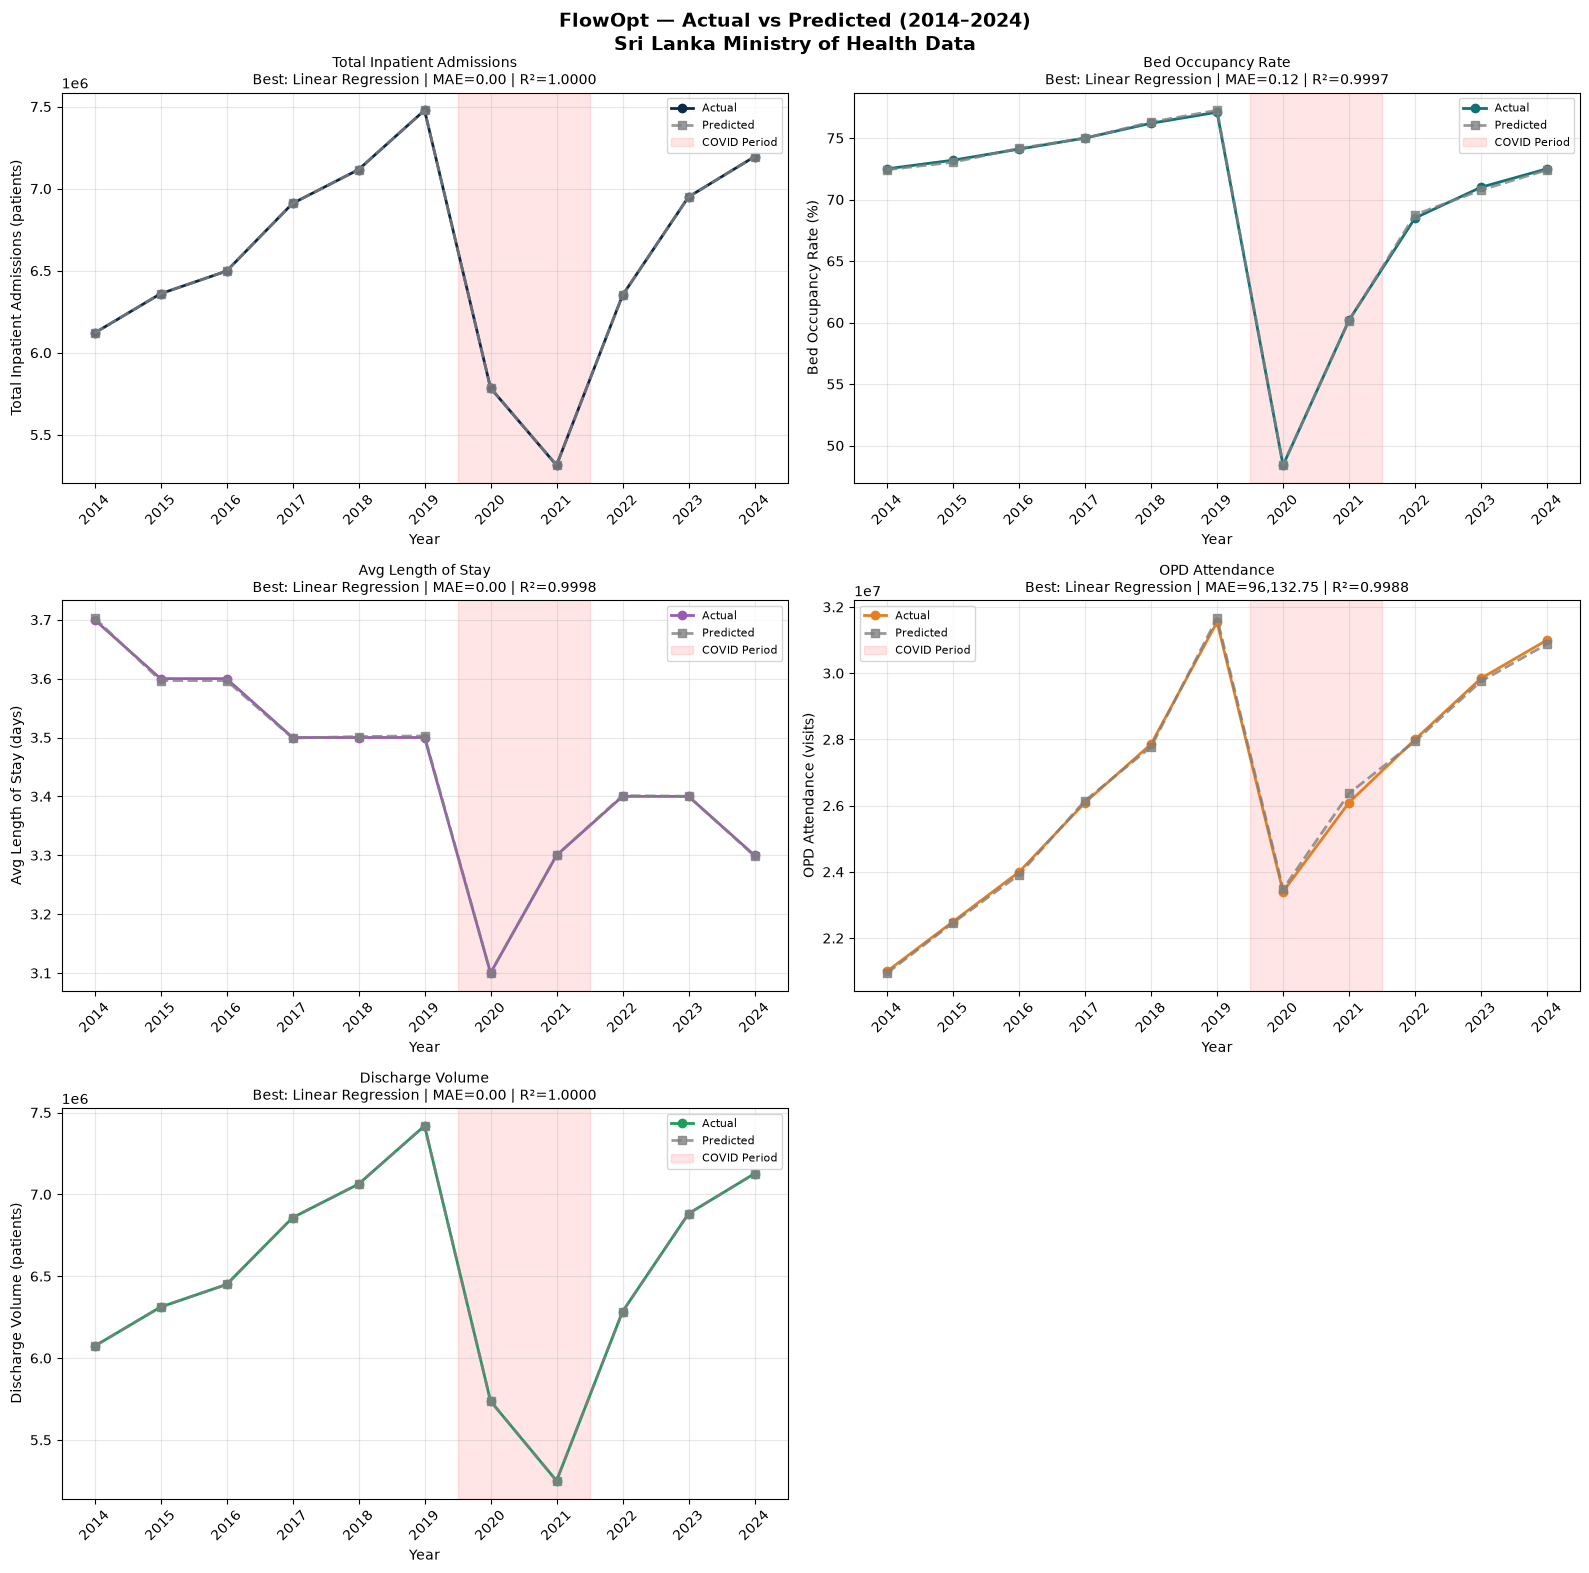

✅ Final chart saved to notebooks/actual_vs_predicted_final.png

✅ WEEK 3 COMPLETE — All 5 models trained and evaluated!


In [22]:
# ── Final proper charts ───────────────────────────────────────────────
colors = ['#0B2A4A','#0D7377','#9B59B6','#E67E22','#1A9E5C']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

fig.suptitle('FlowOpt — Actual vs Predicted (2014–2024)\n'
             'Sri Lanka Ministry of Health Data',
             fontsize=14, fontweight='bold')

for idx, (tc, info) in enumerate(final_summary.items()):
    ax    = axes[idx]
    d     = datasets[tc]
    feat  = [c for c in d.columns
             if c not in ['Year', tc]]
    X     = d[feat]
    y     = d[tc]
    years = d['Year']
    model = all_models[tc][0]

    y_pred = model.predict(X)
    mae    = mean_absolute_error(y, y_pred)
    r2     = r2_score(y, y_pred)

    ax.plot(years, y,
            'o-', color=colors[idx],
            label='Actual', linewidth=2, markersize=6)
    ax.plot(years, y_pred,
            's--', color='gray',
            label='Predicted', linewidth=2,
            markersize=6, alpha=0.8)
    ax.axvspan(2019.5, 2021.5,
               alpha=0.1, color='red',
               label='COVID Period')
    ax.set_title(
        f"{info['name']}\n"
        f"Best: {info['best']} | "
        f"MAE={mae:,.2f} | R²={r2:.4f}",
        fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel(f"{info['name']} ({info['unit']})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)

axes[5].axis('off')
plt.tight_layout()
plt.savefig('notebooks/actual_vs_predicted_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final chart saved to notebooks/actual_vs_predicted_final.png")
print("\n✅ WEEK 3 COMPLETE — All 5 models trained and evaluated!")

In [23]:
# ── Full comparison table — all models all targets ────────────────────
print("="*80)
print("FLOWOPT — COMPLETE MODEL COMPARISON TABLE")
print("All 4 Algorithms × All 5 Prediction Tasks")
print("Metric: Leave-One-Out Cross-Validation MAE")
print("="*80)
print(f"{'Prediction Task':<30} {'Algorithm':<22} {'LOO-CV MAE':>15} {'Note'}")
print("-"*80)

for target_col, (tname, tsave, tunit) in TARGETS_INFO.items():
    for mname in MODELS:
        mae = all_results[target_col][mname]['MAE']
        is_best = "✅ BEST" if mname == best_names[target_col] else ""
        print(f"{tname:<30} {mname:<22} "
              f"{mae:>15,.4f} {tunit}  {is_best}")
    print()

print("="*80)

FLOWOPT — COMPLETE MODEL COMPARISON TABLE
All 4 Algorithms × All 5 Prediction Tasks
Metric: Leave-One-Out Cross-Validation MAE
Prediction Task                Algorithm                   LOO-CV MAE Note
--------------------------------------------------------------------------------
Total Inpatient Admissions     Linear Regression               0.0002 patients  ✅ BEST
Total Inpatient Admissions     Random Forest             254,361.6905 patients  
Total Inpatient Admissions     XGBoost                   240,607.0909 patients  
Total Inpatient Admissions     Gradient Boosting         157,310.9723 patients  

Bed Occupancy Rate             Linear Regression               1.0136 %  ✅ BEST
Bed Occupancy Rate             Random Forest                   4.1051 %  
Bed Occupancy Rate             XGBoost                         4.5423 %  
Bed Occupancy Rate             Gradient Boosting               3.7991 %  

Avg Length of Stay             Linear Regression               0.0136 days  ✅ BEST


In [24]:
# ── Full R² comparison on training data ───────────────────────────────
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

print("="*80)
print("FLOWOPT — FULL R² COMPARISON TABLE")
print("All 4 Algorithms × All 5 Prediction Tasks")
print("Metric: R² on Full Training Data (2014-2024)")
print("="*80)
print(f"{'Prediction Task':<30} {'Algorithm':<22} {'R²':>10} {'Note'}")
print("-"*80)

for target_col, (tname, tsave, tunit) in TARGETS_INFO.items():
    d    = datasets[target_col]
    feat = [c for c in d.columns
            if c not in ['Year', target_col]]
    X = d[feat]
    y = d[target_col]

    model_instances = {
        'Linear Regression': LinearRegression(),
        'Random Forest':     RandomForestRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 random_state=42),
        'XGBoost':           xgb.XGBRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 learning_rate=0.1,
                                 random_state=42,
                                 verbosity=0),
        'Gradient Boosting': GradientBoostingRegressor(
                                 n_estimators=50,
                                 max_depth=2,
                                 learning_rate=0.1,
                                 random_state=42),
    }

    for mname, model in model_instances.items():
        model.fit(X, y)
        y_pred = model.predict(X)
        r2     = r2_score(y, y_pred)
        mae    = mean_absolute_error(y, y_pred)
        is_best = "✅ BEST" if mname == best_names[target_col] else ""
        print(f"{tname:<30} {mname:<22} "
              f"{r2:>10.4f}  {is_best}")
    print()

print("="*80)

FLOWOPT — FULL R² COMPARISON TABLE
All 4 Algorithms × All 5 Prediction Tasks
Metric: R² on Full Training Data (2014-2024)
Prediction Task                Algorithm                      R² Note
--------------------------------------------------------------------------------
Total Inpatient Admissions     Linear Regression          1.0000  ✅ BEST
Total Inpatient Admissions     Random Forest              0.9303  
Total Inpatient Admissions     XGBoost                    0.9959  
Total Inpatient Admissions     Gradient Boosting          0.9999  

Bed Occupancy Rate             Linear Regression          0.9997  ✅ BEST
Bed Occupancy Rate             Random Forest              0.9048  
Bed Occupancy Rate             XGBoost                    0.9939  
Bed Occupancy Rate             Gradient Boosting          0.9997  

Avg Length of Stay             Linear Regression          0.9998  ✅ BEST
Avg Length of Stay             Random Forest              0.8030  
Avg Length of Stay             XGBoos